In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [2]:
pd.set_option("display.max_columns", None)

### 1. Verisetine Genel Bakış

In [3]:
df = pd.read_csv("fifa_players.csv")

In [4]:
df.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,wage_euro,preferred_foot,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),body_type,release_clause_euro,national_team,national_rating,national_team_position,national_jersey_number,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,565000.0,Left,5,4,4,Messi,226500000.0,Argentina,82.0,RF,10.0,86,95,70,92,86,97,93,94,89,96,91,86,93,95,95,85,68,72,66,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,205000.0,Right,3,5,4,Lean,133800000.0,Denmark,78.0,CAM,10.0,88,81,52,91,80,84,86,87,89,91,76,73,80,88,81,84,50,92,58,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,255000.0,Right,4,4,5,Normal,144200000.0,France,84.0,RDM,6.0,80,75,75,86,85,87,85,82,90,90,71,79,76,82,66,90,83,88,87,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,165000.0,Right,3,4,4,Normal,105400000.0,Italy,83.0,LW,10.0,86,77,56,85,74,90,87,77,78,93,94,86,94,83,93,75,53,75,44,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,60000000.0,135000.0,Right,3,3,2,Normal,106500000.0,NaN,NaN,NaN,NaN,30,22,83,68,14,69,28,28,60,63,70,75,50,82,40,55,81,75,94,15,87,88,24,49,33,80,91,88,87


In [5]:
df.shape

(17954, 51)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

In [7]:
df.drop(["name", "full_name", "birth_date", "nationality"], axis= 1, inplace= True)

### 2. Tekrar Eden Kayıtlar

In [8]:
df.duplicated().sum()

np.int64(0)

### 3. Eksik Değerler

In [9]:
df.isna().sum().sum()

np.int64(70726)

In [10]:
df.isna().sum()

age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type                            0
release_clause_euro               1837
national_team                    17097
national_rating                  17097
national_team_position           17097
national_jersey_number           17097
crossing                             0
finishing                            0
heading_accuracy                     0
short_passing                        0
volleys                              0
dribbling                            0
curve                                0
freekick_accuracy        

In [11]:
df.drop(["national_team", "national_rating", "national_team_position", "national_jersey_number"], axis= 1, inplace= True)

In [12]:
df["release_clause_euro"] = df["release_clause_euro"].fillna(0)

In [13]:
df.dropna(subset= ["value_euro", "wage_euro"], inplace= True)

In [14]:
df.isna().sum().sum()

np.int64(0)

### 4. Aykırı Değerler

In [15]:
outlier_cols = ["age", "height_cm", "weight_kgs", "overall_rating", "potential", "value_euro", "wage_euro", "release_clause_euro"]

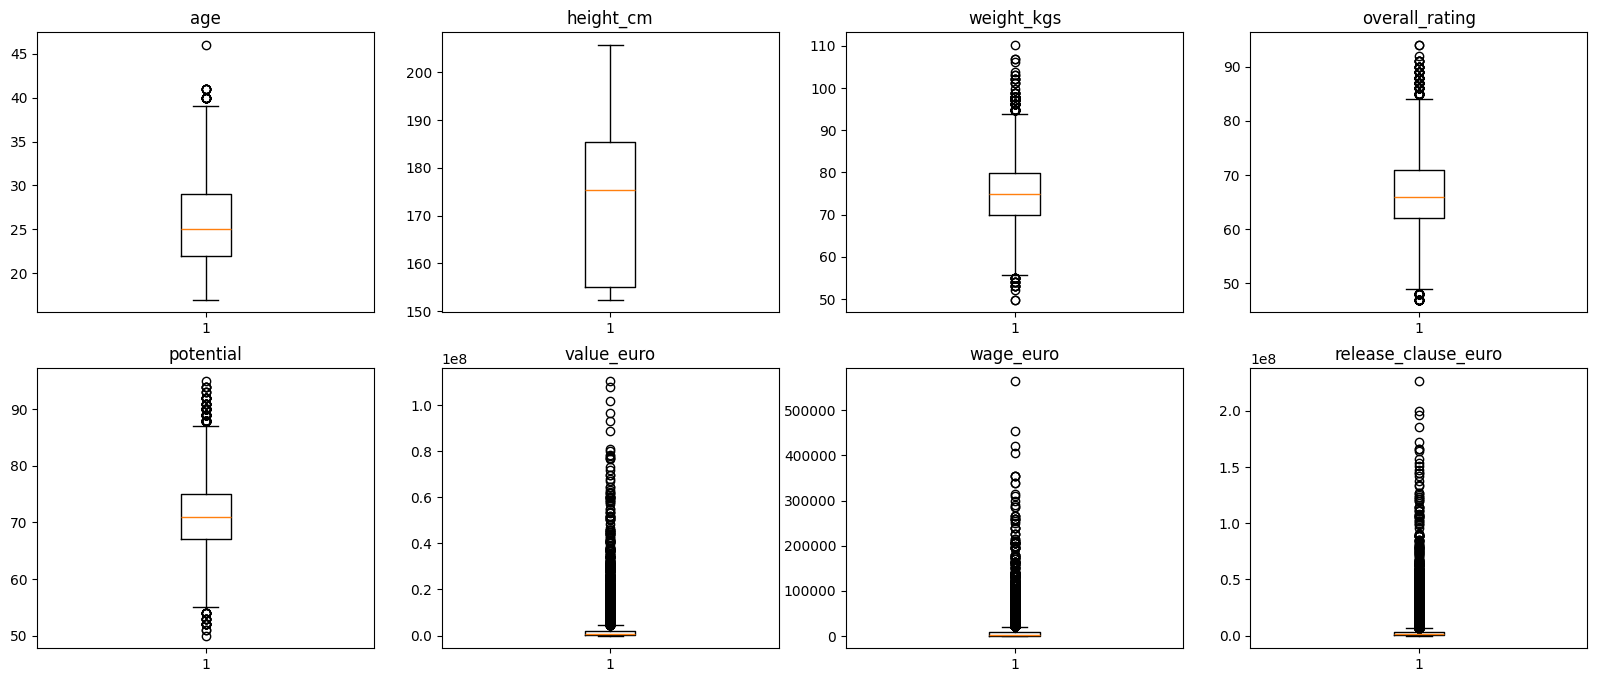

In [16]:
plt.figure(figsize= (20, 8))

for i, column in enumerate(outlier_cols, 1):
    plt.subplot(2, 4, i)
    plt.boxplot(df[column])
    plt.title(column)

plt.show()

In [17]:
for column in outlier_cols:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column}: {len(outliers)}")

age: 21
height_cm: 0
weight_kgs: 115
overall_rating: 161
potential: 159
value_euro: 2419
wage_euro: 2001
release_clause_euro: 2655


### 5. Hedef Değişken Analizi

In [18]:
target_col = df["value_euro"]

In [19]:
round(target_col.describe())

count        17699.0
mean       2479280.0
std        5687014.0
min          10000.0
25%         325000.0
50%         700000.0
75%        2100000.0
max      110500000.0
Name: value_euro, dtype: float64

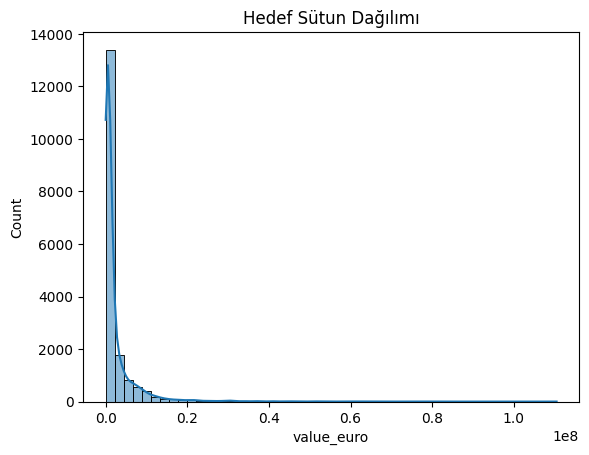

In [20]:
sns.histplot(target_col, bins= 50, kde= True)
plt.title("Hedef Sütun Dağılımı")
plt.show()

In [21]:
target_col.skew()

np.float64(6.940056316296809)

### 6. Kategorik Değişken Analizi

In [22]:
cat_analysis_cols = df.select_dtypes(include= ["object"]).columns

In [23]:
for column in cat_analysis_cols:
    print(f"{df[column].value_counts()}\n")

positions
CB               2207
GK               2024
ST               1725
CM                753
CDM,CM            700
                 ... 
CDM,CM,RB,RM        1
RB,RWB,RM,LWB       1
CAM,LM,RM,CF        1
ST,LW,RM            1
RB,LB,LM,RM         1
Name: count, Length: 884, dtype: int64

preferred_foot
Right    13579
Left      4120
Name: count, dtype: int64

body_type
Normal                 10223
Lean                    6400
Stocky                  1069
Messi                      1
Courtois                   1
PLAYER_BODY_TYPE_25        1
Akinfenwa                  1
Shaqiri                    1
Neymar                     1
C. Ronaldo                 1
Name: count, dtype: int64



In [24]:
df = df[df["body_type"] != "PLAYER_BODY_TYPE_25"]

df["body_type"] = df["body_type"].replace(["Messi", "Courtois", "Akinfenwa", "Shaqiri", "Neymar", "C. Ronaldo"], "Special")

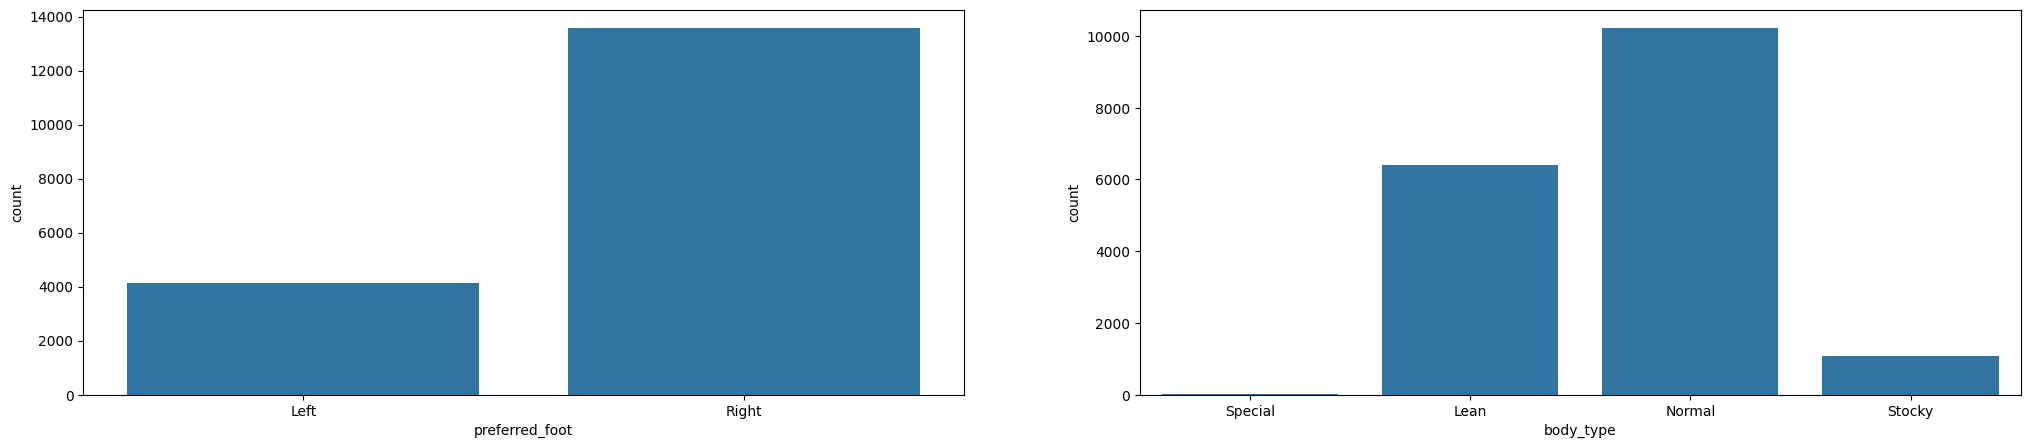

In [25]:
plt.figure(figsize= (25, 5))

for i, column in enumerate(df[["preferred_foot", "body_type"]], 1):
    plt.subplot(1, 2, i)
    sns.countplot(df, x= column)

plt.show()

In [26]:
df = df[df["positions"] != "GK"]

In [27]:
df.shape

(15674, 43)

### 7. Sayısal Değişken Analizi

In [28]:
num_analysis_cols = df.drop(["value_euro", "international_reputation(1-5)", "weak_foot(1-5)", "skill_moves(1-5)"], axis= 1).select_dtypes(include= ["int64", "float64"]).columns

In [29]:
df[num_analysis_cols].describe()

,age,height_cm,weight_kgs,overall_rating,potential,wage_euro,release_clause_euro,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
count,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,1.567400e+04,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000,15674.000000
mean,25.423568,173.423629,74.437106,66.450555,71.652099,10298.456042,4.373964e+06,54.301455,49.706138,57.048935,62.648845,46.716792,60.691017,51.340819,46.357407,56.146102,63.223746,68.171813,68.255519,66.426375,62.207669,66.586832,59.579622,65.955021,67.398112,65.784229,51.314534,59.670027,50.517417,54.906150,55.530560,52.025010,60.508103,51.322253,52.088873,49.809557
std,4.576417,13.820232,6.722649,6.842879,6.079830,22484.820266,1.098668e+07,14.114431,16.388072,11.590911,9.808845,14.784407,12.485542,15.176394,15.107302,12.388049,10.026394,11.553410,11.231915,12.271492,8.808167,12.132345,13.262312,11.390191,10.924845,12.574789,15.807957,14.305223,18.749120,14.664314,12.890846,12.519386,10.148604,17.213785,19.038372,19.032213
min,17.000000,152.400000,49.900000,47.000000,51.000000,1000.000000,0.000000e+00,11.000000,10.000000,18.000000,20.000000,10.000000,16.000000,11.000000,10.000000,19.000000,25.000000,20.000000,25.000000,23.000000,30.000000,21.000000,15.000000,25.000000,28.000000,25.000000,11.000000,13.000000,10.000000,11.000000,12.000000,11.000000,30.000000,10.000000,10.000000,10.000000
25%,22.000000,154.940000,69.900000,62.000000,67.000000,1000.000000,4.280000e+05,44.000000,36.000000,49.000000,57.000000,35.000000,55.000000,39.000000,34.000000,49.000000,58.000000,62.000000,62.000000,59.000000,56.000000,60.000000,51.000000,59.000000,61.000000,58.000000,40.000000,50.000000,34.000000,46.000000,47.000000,42.000000,54.000000,38.000000,35.000000,32.000000
50%,25.000000,175.260000,73.900000,66.000000,71.000000,3000.000000,1.100000e+06,57.000000,52.000000,58.000000,64.000000,47.000000,63.000000,52.000000,44.000000,58.000000,64.000000,69.000000,69.000000,68.000000,62.000000,68.000000,61.000000,67.000000,68.000000,67.000000,54.000000,61.000000,56.000000,57.000000,57.000000,52.000000,61.000000,56.000000,59.000000,56.000000
75%,29.000000,185.420000,78.900000,71.000000,76.000000,10000.000000,3.200000e+06,65.000000,63.000000,65.000000,69.000000,58.000000,69.000000,63.000000,58.000000,65.000000,70.000000,76.000000,76.000000,75.000000,68.000000,75.000000,69.000000,74.000000,75.000000,75.000000,64.000000,70.000000,65.000000,65.000000,65.000000,61.000000,68.000000,65.000000,67.000000,65.000000
max,40.000000,203.200000,110.200000,94.000000,95.000000,565000.000000,2.265000e+08,93.000000,95.000000,94.000000,93.000000,90.000000,97.000000,94.000000,94.000000,93.000000,96.000000,97.000000,96.000000,96.000000,96.000000,96.000000,95.000000,95.000000,97.000000,97.000000,94.000000,95.000000,92.000000,95.000000,94.000000,92.000000,96.000000,94.000000,93.000000,90.000000


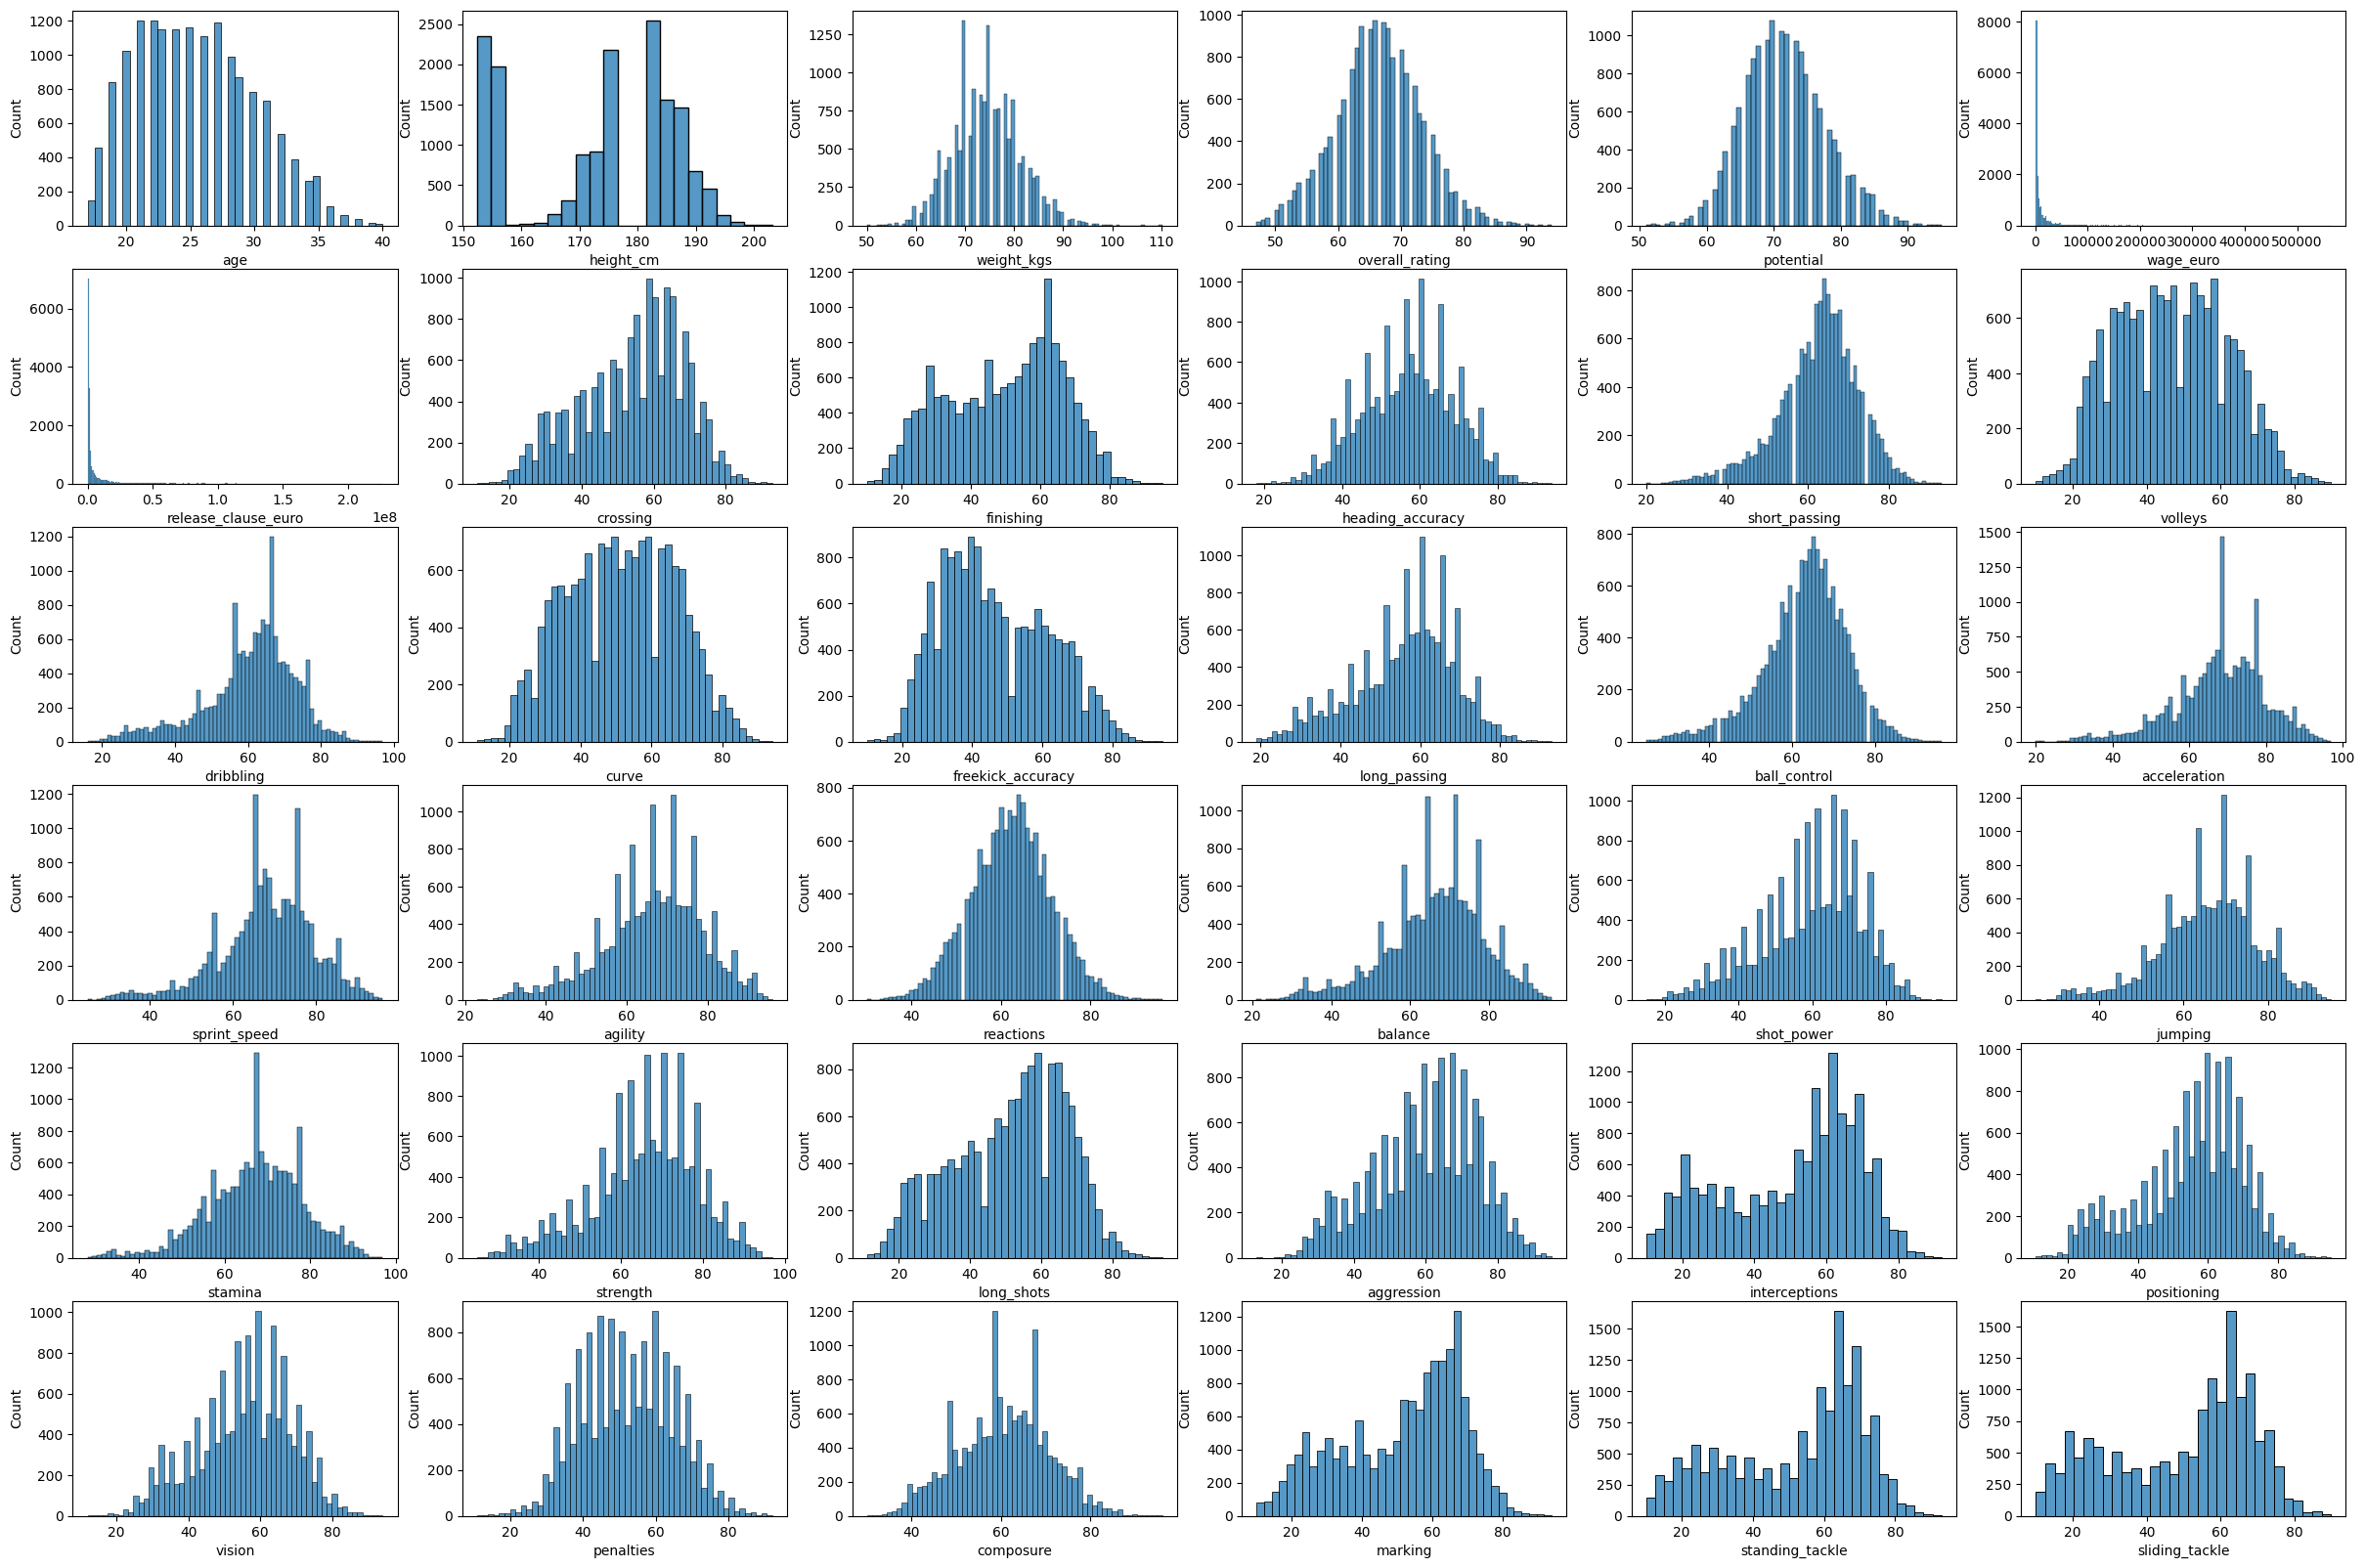

In [30]:
plt.figure(figsize= (30, 20))

for i, column in enumerate(num_analysis_cols, 1):
    plt.subplot(6, 6, i)
    sns.histplot(df, x= column)

plt.show()

### 8. Veri Görselleştirme

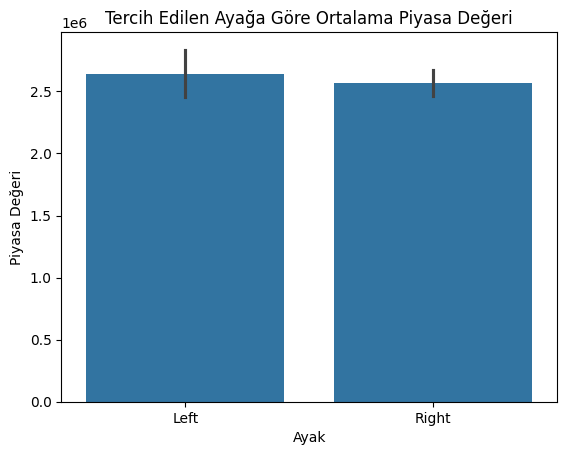

In [31]:
sns.barplot(df, x= "preferred_foot", y= "value_euro")
plt.title("Tercih Edilen Ayağa Göre Ortalama Piyasa Değeri")
plt.xlabel("Ayak")
plt.ylabel("Piyasa Değeri")
plt.show()

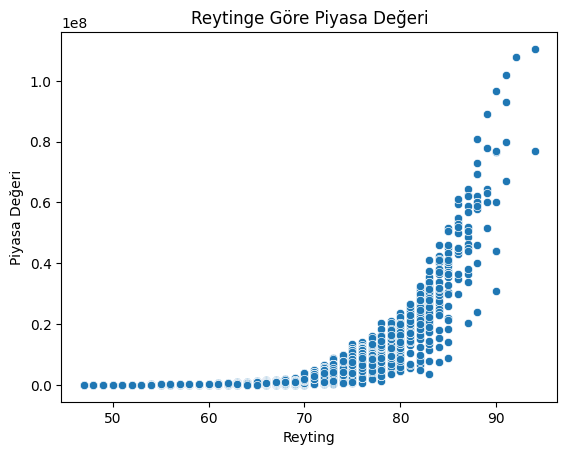

In [32]:
sns.scatterplot(df, x= "overall_rating", y= "value_euro")
plt.title("Reytinge Göre Piyasa Değeri")
plt.xlabel("Reyting")
plt.ylabel("Piyasa Değeri")
plt.show()

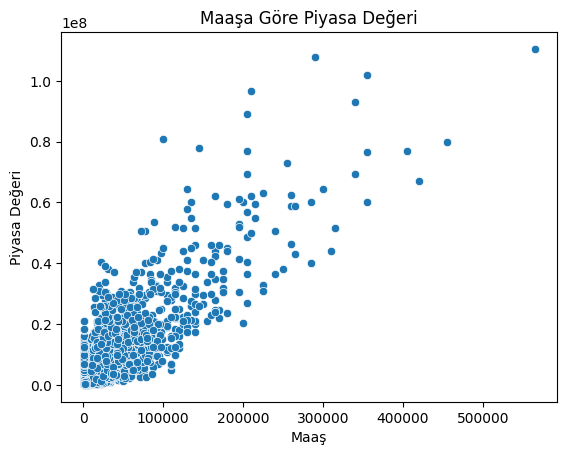

In [33]:
sns.scatterplot(df, x= "wage_euro", y= "value_euro")
plt.title("Maaşa Göre Piyasa Değeri")
plt.xlabel("Maaş")
plt.ylabel("Piyasa Değeri")
plt.show()

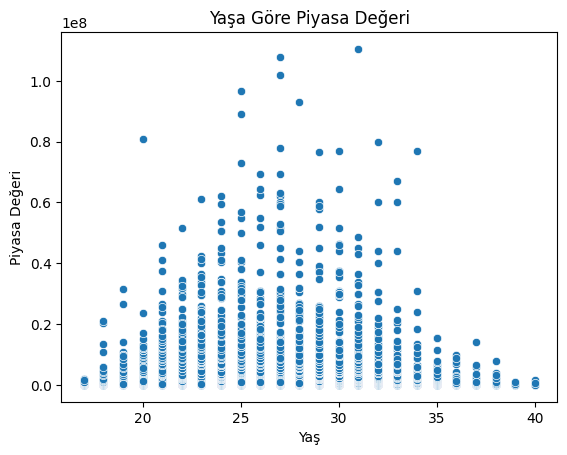

In [34]:
sns.scatterplot(df, x= "age", y= "value_euro")
plt.title("Yaşa Göre Piyasa Değeri")
plt.xlabel("Yaş")
plt.ylabel("Piyasa Değeri")
plt.show()

### 9. Korelasyon Analizi

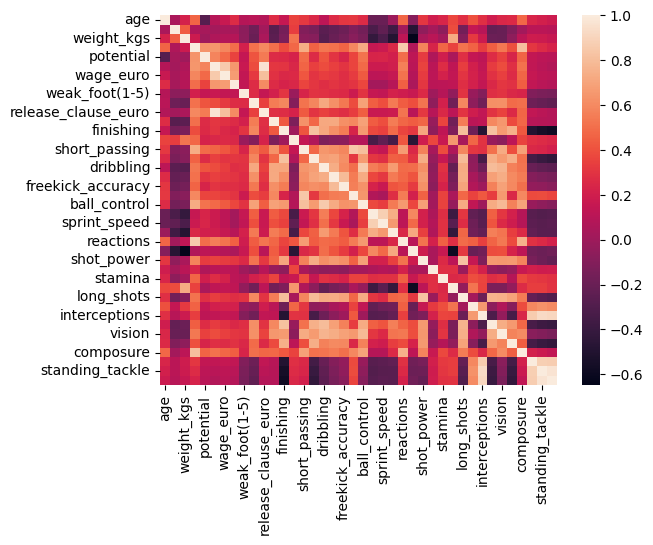

In [35]:
sns.heatmap(df.corr(numeric_only= True))
plt.show()

In [36]:
df.corr(numeric_only= True)["value_euro"].sort_values(ascending= False)

value_euro                       1.000000
release_clause_euro              0.962380
wage_euro                        0.854461
international_reputation(1-5)    0.648161
overall_rating                   0.640095
potential                        0.577145
reactions                        0.561182
composure                        0.509957
ball_control                     0.484962
short_passing                    0.465499
vision                           0.386081
dribbling                        0.386002
skill_moves(1-5)                 0.384867
long_passing                     0.361041
shot_power                       0.356197
curve                            0.343362
volleys                          0.341022
long_shots                       0.336216
positioning                      0.329849
crossing                         0.308517
freekick_accuracy                0.304839
finishing                        0.299573
penalties                        0.284175
stamina                          0

In [37]:
df.drop(["release_clause_euro", "wage_euro"], axis= 1, inplace= True)

### 10. Öznitelik Mühendisliği

In [38]:
df.columns

Index(['age', 'height_cm', 'weight_kgs', 'positions', 'overall_rating',
       'potential', 'value_euro', 'preferred_foot',
       'international_reputation(1-5)', 'weak_foot(1-5)', 'skill_moves(1-5)',
       'body_type', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'composure', 'marking', 'standing_tackle',
       'sliding_tackle'],
      dtype='object')

In [39]:
df["bmi"] = df["weight_kgs"] / ((df["height_cm"] / 100) ** 2)

In [40]:
df["positions"].unique()

array(['CF,RW,ST', 'CAM,RM,CM', 'CM,CAM', 'LW,ST', 'CB', 'RW,ST,RM', 'ST',
       'CDM,CM', 'CF,ST', 'CAM,RW', 'CDM', 'CM,CDM', 'LB', 'CM,CAM,CDM',
       'CAM,CM,LW', 'CAM,CM,RM', 'LW,ST,LM', 'CAM,CM', 'CAM', 'LW,RW',
       'RW,LW', 'CM,LM', 'CM', 'RM,RW', 'LM,RM,CAM,LW', 'LM', 'RW,RM',
       'LM,ST,RM', 'RB', 'LM,RM,LW,RW', 'LM,CAM,RM', 'RM,LM,ST', 'RW',
       'LM,ST,RM,LW', 'CM,CDM,CAM', 'CM,CDM,CB', 'CB,CDM', 'CF,ST,CAM',
       'CDM,CB', 'RB,RWB', 'RM', 'LM,CAM', 'CM,LW', 'LB,LWB,LM', 'ST,LW',
       'LM,LB,CM', 'RB,RM', 'RM,LM,CM', 'LM,RM,CAM', 'RM,RW,ST',
       'LW,LM,RW', 'LB,LM', 'ST,LW,LM', 'RM,CM', 'CM,RM', 'CB,RB',
       'RM,RW,LM', 'LM,RM', 'CDM,CB,CM', 'CAM,CDM', 'LB,CDM', 'CAM,RM,LM',
       'RM,CAM,CM', 'LWB', 'CDM,CM,LM', 'CDM,CM,RM', 'CDM,CM,CB',
       'CAM,LW', 'RM,LM', 'ST,CAM', 'LM,CM', 'ST,CF,CAM,LM',
       'LWB,LB,CB,LM', 'RB,LB', 'LW', 'CAM,ST', 'LM,RM,LW', 'LWB,LM,LB',
       'ST,CF,LM,CAM', 'LM,LW,ST', 'LB,LWB', 'RWB,RB,RM', 'ST,RW',
       'CAM,CM,LM',

In [41]:
group_and_positions = {
    "defender": ["LWB", "LB", "CB", "RB", "RWB"],
    "midfielder": ["LM", "CM", "RM", "CAM", "CDM"],
    "attacker": ["LW", "ST", "CF", "RW"]
}

In [42]:
def get_position_group(positions):
    primary_position = positions.split(",")[0]

    for group, position_list in group_and_positions.items():
        if primary_position in position_list:
            return group

In [43]:
df["position_group"] = df["positions"].apply(get_position_group)

In [44]:
df["position_count"] = df["positions"].str.split(",").str.len()

In [45]:
df.drop("positions", axis= 1, inplace= True)

##### https://www.ea.com/games/ea-sports-fc/ratings/player-ratings/mohamed-salah/209331

In [46]:
pace_cols = ["acceleration", "sprint_speed"]

In [47]:
shooting_cols = [
    "finishing", "volleys", "shot_power", "long_shots", "positioning", "penalties", 
]

In [48]:
passing_cols = [
    "crossing", "short_passing", "curve", "freekick_accuracy", "long_passing", "vision", 
]

In [49]:
dribbling_cols = [
    "dribbling", "ball_control", "agility", "reactions", "balance", "composure", 
]

In [50]:
defending_cols = [
    "heading_accuracy", "interceptions", "marking", "standing_tackle", "sliding_tackle"
]

In [51]:
physical_cols = [
    "jumping", "stamina", "strength", "aggression", 
]

In [52]:
df["pace_score"] = df[pace_cols].mean(axis= 1)

In [53]:
df["shooting_score"] = df[shooting_cols].mean(axis= 1)

In [54]:
df["passing_score"] = df[passing_cols].mean(axis= 1)

In [55]:
df["dribbling_score"] = df[dribbling_cols].mean(axis= 1)

In [56]:
df["defending_score"] = df[defending_cols].mean(axis= 1)

In [57]:
df["physical_score"] = df[physical_cols].mean(axis= 1)

In [58]:
df.corr(numeric_only= True)["value_euro"].sort_values(ascending= False)

value_euro                       1.000000
international_reputation(1-5)    0.648161
overall_rating                   0.640095
potential                        0.577145
reactions                        0.561182
composure                        0.509957
ball_control                     0.484962
dribbling_score                  0.469261
short_passing                    0.465499
passing_score                    0.417951
vision                           0.386081
dribbling                        0.386002
skill_moves(1-5)                 0.384867
shooting_score                   0.365054
long_passing                     0.361041
shot_power                       0.356197
curve                            0.343362
volleys                          0.341022
long_shots                       0.336216
positioning                      0.329849
crossing                         0.308517
freekick_accuracy                0.304839
finishing                        0.299573
penalties                        0

In [59]:
df.drop(
    ['crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'freekick_accuracy', 'long_passing',
       'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions',
       'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle'], axis= 1, inplace= True
)

In [60]:
df["value_euro_log"] = np.log(df["value_euro"])

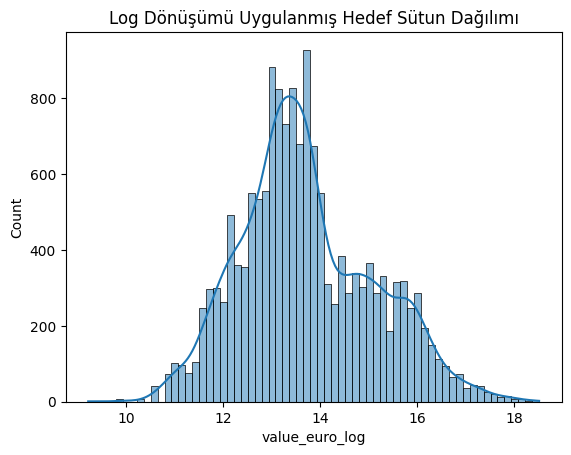

In [61]:
sns.histplot(df["value_euro_log"],  kde= True)
plt.title("Log Dönüşümü Uygulanmış Hedef Sütun Dağılımı")
plt.show()

In [62]:
df["value_euro_log"].skew()

np.float64(0.40518676705242973)

In [63]:
df.corr(numeric_only= True)["value_euro_log"].sort_values(ascending= False)

value_euro_log                   1.000000
overall_rating                   0.949151
potential                        0.772901
value_euro                       0.679744
dribbling_score                  0.678281
passing_score                    0.614312
skill_moves(1-5)                 0.551900
shooting_score                   0.528533
international_reputation(1-5)    0.462503
physical_score                   0.430932
pace_score                       0.266213
defending_score                  0.251541
weak_foot(1-5)                   0.216215
age                              0.207268
position_count                   0.150449
weight_kgs                       0.122980
height_cm                        0.048778
bmi                              0.017778
Name: value_euro_log, dtype: float64

In [64]:
round(df.corr(numeric_only= True)[["value_euro", "value_euro_log"]], 3)

,value_euro,value_euro_log
age,0.089,0.207
height_cm,0.024,0.049
weight_kgs,0.062,0.123
overall_rating,0.640,0.949
potential,0.577,0.773
value_euro,1.000,0.680
international_reputation(1-5),0.648,0.463
weak_foot(1-5),0.169,0.216
skill_moves(1-5),0.385,0.552
bmi,0.008,0.018


### 11. Modellemeye Hazırlık

In [65]:
X = df.drop(["value_euro", "value_euro_log"], axis= 1)
y = df["value_euro_log"]

In [66]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size= 0.15, random_state= 42)

In [67]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size= 0.15, random_state= 42)

In [68]:
X_train.shape, X_val.shape, X_test.shape

((11323, 19), (1999, 19), (2352, 19))

In [69]:
categoric_cols = X.select_dtypes(include= "object").columns
numeric_cols = X.select_dtypes(exclude= "object").columns

In [70]:
preprocessor = ColumnTransformer(
    transformers= [
        ("cat", OneHotEncoder(drop= "first", sparse_output= False, handle_unknown= "ignore"), categoric_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [71]:
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

In [72]:
y_train_original = np.exp(y_train)
y_val_original = np.exp(y_val)
y_test_original = np.exp(y_test)

In [73]:
def predict_and_evaluate(model, Xtest, ytest_original):
    y_pred = model.predict(Xtest)

    y_pred_original = np.exp(y_pred)

    print(f"MAE: {int(mean_absolute_error(ytest_original, y_pred_original))}")
    print(f"RMSE: {int(root_mean_squared_error(ytest_original, y_pred_original))}")
    print(f"R2: {round(r2_score(ytest_original, y_pred_original), 2)}")

### 12. Linear Regression

In [74]:
linear = LinearRegression().fit(X_train, y_train)

### 13. Ridge Regression

In [75]:
ridge = Ridge(random_state= 42).fit(X_train, y_train)

### 14. Lasso Regression

In [76]:
lasso = Lasso(alpha= 0.1, random_state= 42).fit(X_train, y_train)

### 15. Polynomial Regression

In [77]:
polynomial_features = PolynomialFeatures(degree= 2, include_bias= False)

X_train_poly = polynomial_features.fit_transform(X_train)
X_val_poly = polynomial_features.transform(X_val)

In [78]:
polynomial = LinearRegression().fit(X_train_poly, y_train)

### 16. Modelleri Karşılaştırma

#### 16.1 Linear Regression

In [79]:
predict_and_evaluate(linear, X_val, y_val_original)

MAE: 541581
RMSE: 2787109
R2: 0.78


#### 16.2 Ridge Regression

In [80]:
predict_and_evaluate(ridge, X_val, y_val_original)

MAE: 540633
RMSE: 2775804
R2: 0.79


#### 16.3 Lasso Regression

In [81]:
predict_and_evaluate(lasso, X_val, y_val_original)

MAE: 689478
RMSE: 1743408
R2: 0.92


#### 16.4 Polynomial Regression

In [82]:
predict_and_evaluate(polynomial, X_val_poly, y_val_original)

MAE: 374916
RMSE: 1635408
R2: 0.93


In [83]:
predict_and_evaluate(polynomial, X_train_poly, y_train_original)

MAE: 373668
RMSE: 1673527
R2: 0.91


### 17. Açıklanabilirlik

In [84]:
feature_and_coef = pd.Series(
    data= polynomial.coef_,
    index= polynomial_features.get_feature_names_out(preprocessor.get_feature_names_out())
).abs().sort_values(ascending= False).head(20)

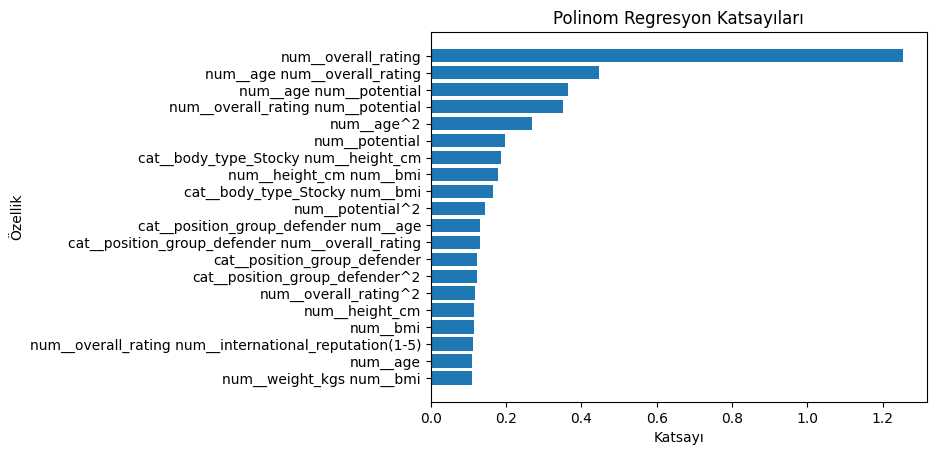

In [85]:
plt.barh(y= feature_and_coef.index, width= feature_and_coef.values)
plt.title("Polinom Regresyon Katsayıları")
plt.xlabel("Katsayı"),
plt.ylabel("Özellik"),
plt.gca().invert_yaxis()
plt.show()

### 18. Test Veriseti Üzerinde Değerlendirme

In [86]:
X_test_poly = polynomial_features.transform(X_test)

In [87]:
predict_and_evaluate(polynomial, X_test_poly, y_test_original)

MAE: 355640
RMSE: 1248964
R2: 0.97
